# R08 — Gun Selection & Virtual Gun Performance

**Goal:** Evaluate which gun strategy the Virtual Gun Manager (VGM) selects,
how each gun’s hit rate evolves across a battle, and whether the VGM’s
selection policy is effective.

The `internal.csv` records per-tick state including:
- `selected_gun_idx` — which gun the VGM chose to fire with
- `gun_hr_0` … `gun_hr_5` — cumulative hit rate per virtual gun
- `fire_power_budget` — chosen fire power
- `aggression` — strategy aggression level (0–1)

**Gun index mapping:** 0=HeadOn, 1=Linear, 2=Circular, 3=VCS, 4=Predictive, 5=RandomGF (if present)

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_internal
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

df = load_local_internal()
print(f'Loaded {len(df):,} internal ticks from {df.battle_id.nunique()} battles')
print(f'Opponents: {sorted(df.opponent_name.unique())}')

Loaded 136,621 internal ticks from 25 battles
Opponents: ['DengerousRoBatra 1.3', 'Glacier 0.3.2', 'Midboss 1q.fast', 'ScalarR 0.005h.053-noshield', 'Shadow 3.83c']


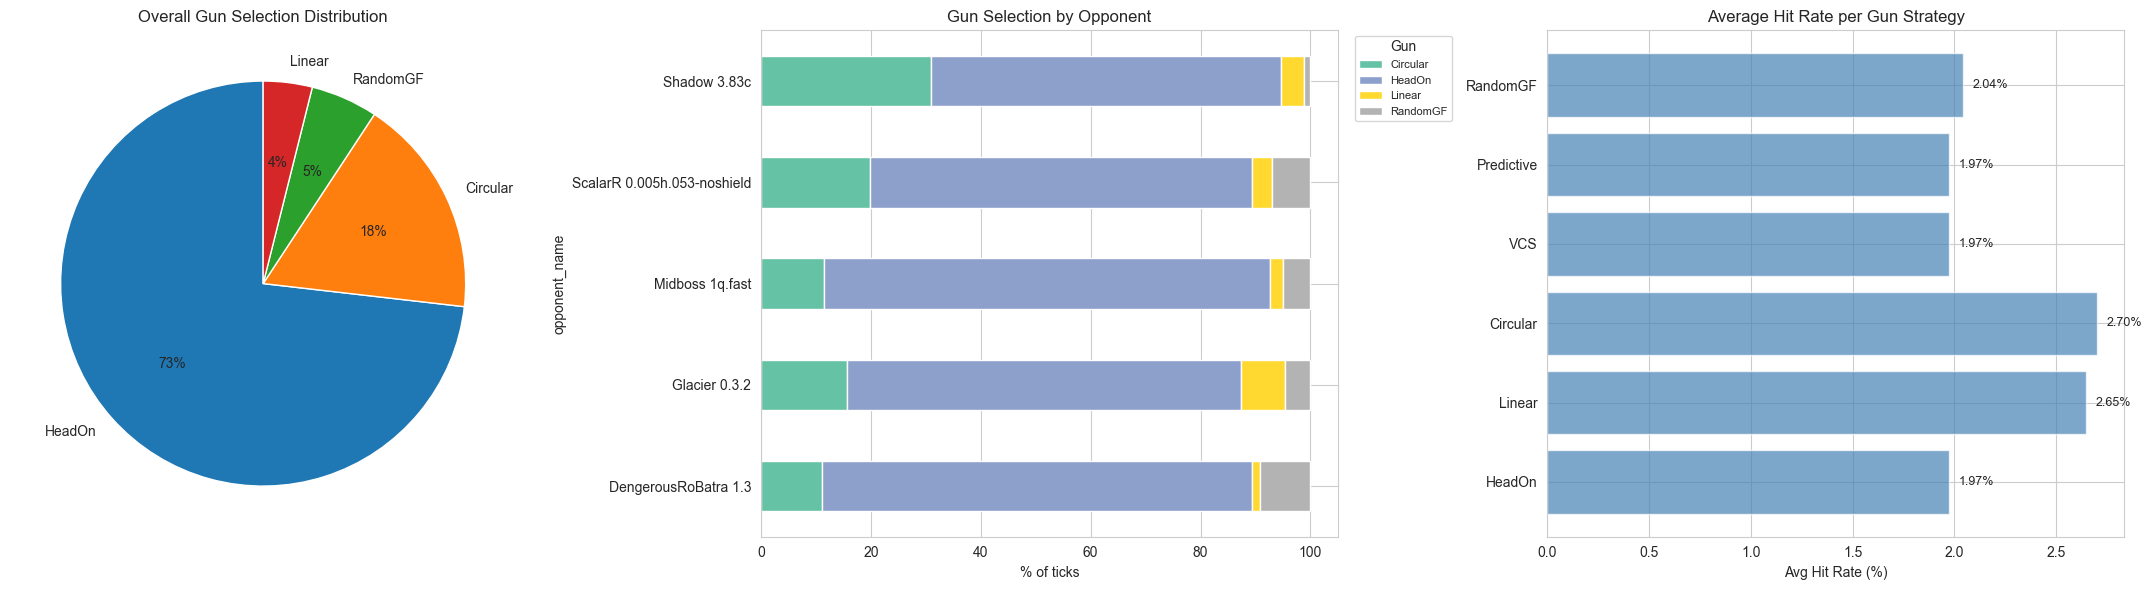


=== Gun Hit Rate Summary ===
  Circular    : 2.700%
  Linear      : 2.646%
  RandomGF    : 2.041%
  HeadOn      : 1.972%
  VCS         : 1.972%
  Predictive  : 1.972%


In [2]:
# --- Gun selection distribution ---
gun_names = {0: 'HeadOn', 1: 'Linear', 2: 'Circular', 3: 'VCS', 4: 'Predictive', 5: 'RandomGF'}
df['gun_name'] = df['selected_gun_idx'].map(gun_names).fillna(f'Gun_{df["selected_gun_idx"]}')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Overall gun selection pie
ax = axes[0]
counts = df['gun_name'].value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.0f%%', startangle=90)
ax.set_title('Overall Gun Selection Distribution')

# 2. Gun selection per opponent
ax = axes[1]
ct = pd.crosstab(df['opponent_name'], df['gun_name'], normalize='index') * 100
ct.plot.barh(stacked=True, ax=ax, colormap='Set2')
ax.set_xlabel('% of ticks')
ax.set_title('Gun Selection by Opponent')
ax.legend(title='Gun', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

# 3. Gun hit rates comparison
ax = axes[2]
hr_cols = [c for c in df.columns if c.startswith('gun_hr_')]
hr_means = {gun_names.get(int(c.split('_')[-1]), c): df[c].mean() * 100 for c in hr_cols}
bars = ax.barh(list(hr_means.keys()), list(hr_means.values()), color='steelblue', alpha=0.7)
ax.set_xlabel('Avg Hit Rate (%)')
ax.set_title('Average Hit Rate per Gun Strategy')
for bar, v in zip(bars, hr_means.values()):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary table
print('\n=== Gun Hit Rate Summary ===')
for name, hr in sorted(hr_means.items(), key=lambda x: -x[1]):
    print(f'  {name:12s}: {hr:.3f}%')

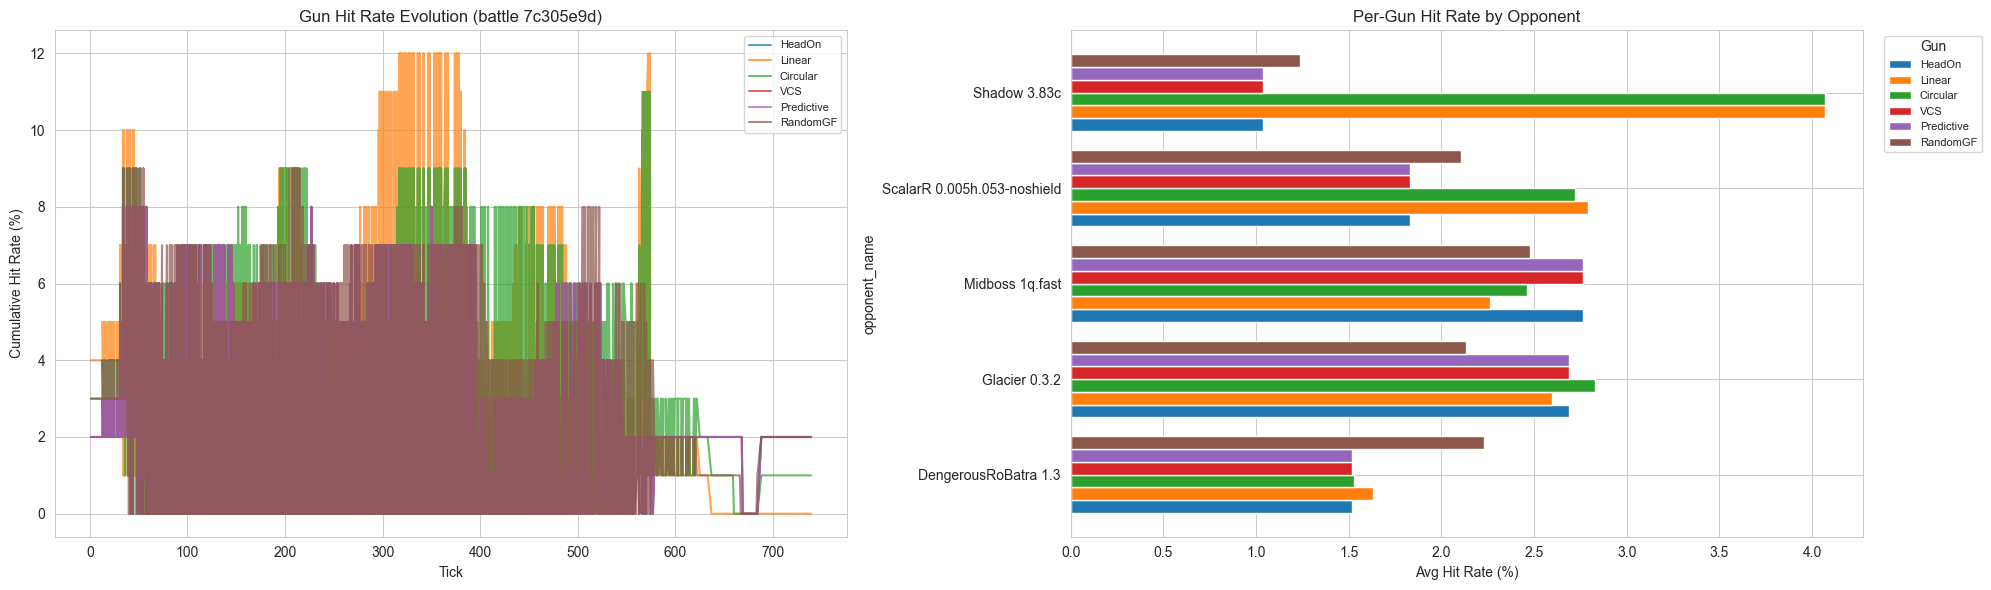

In [3]:
# --- Gun hit rate evolution over time within a battle ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Left: hit rates evolving over ticks (first battle as example)
ax = axes[0]
sample_battle = df['battle_id'].value_counts().idxmax()
bdf = df[df['battle_id'] == sample_battle].sort_values('tick')
for c in hr_cols:
    gname = gun_names.get(int(c.split('_')[-1]), c)
    ax.plot(bdf['tick'], bdf[c] * 100, label=gname, alpha=0.7)
ax.set_xlabel('Tick')
ax.set_ylabel('Cumulative Hit Rate (%)')
ax.set_title(f'Gun Hit Rate Evolution (battle {sample_battle[:8]})')
ax.legend(fontsize=8)

# Right: per-opponent hit rates
ax = axes[1]
opp_hr = df.groupby('opponent_name')[hr_cols].mean() * 100
opp_hr.columns = [gun_names.get(int(c.split('_')[-1]), c) for c in hr_cols]
opp_hr.plot.barh(ax=ax, width=0.8)
ax.set_xlabel('Avg Hit Rate (%)')
ax.set_title('Per-Gun Hit Rate by Opponent')
ax.legend(title='Gun', fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

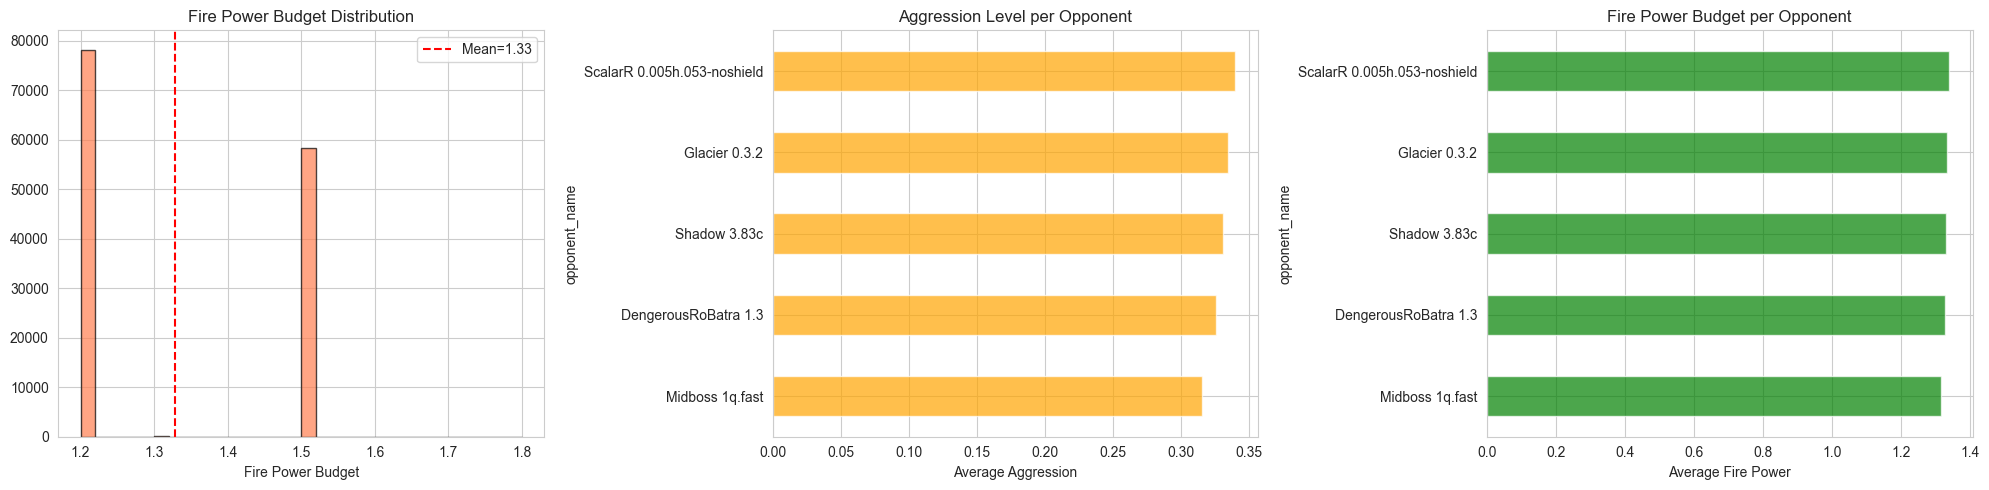

=== Gun Selection Diagnostics ===
Total ticks analyzed: 136,621
VGM selects HeadOn gun 73% of the time
Best gun by hit rate: Circular (2.700%)
Avg fire power: 1.33
Avg aggression: 0.33


In [4]:
# --- Fire power budget & aggression ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Fire power budget distribution
ax = axes[0]
df['fire_power_budget'].hist(ax=ax, bins=30, color='coral', alpha=0.7, edgecolor='black')
ax.axvline(df['fire_power_budget'].mean(), color='red', linestyle='--', label=f'Mean={df["fire_power_budget"].mean():.2f}')
ax.set_xlabel('Fire Power Budget')
ax.set_title('Fire Power Budget Distribution')
ax.legend()

# Aggression per opponent
ax = axes[1]
agg = df.groupby('opponent_name')['aggression'].mean().sort_values()
agg.plot.barh(ax=ax, color='orange', alpha=0.7)
ax.set_xlabel('Average Aggression')
ax.set_title('Aggression Level per Opponent')

# Fire power by opponent
ax = axes[2]
fp = df.groupby('opponent_name')['fire_power_budget'].mean().sort_values()
fp.plot.barh(ax=ax, color='green', alpha=0.7)
ax.set_xlabel('Average Fire Power')
ax.set_title('Fire Power Budget per Opponent')

plt.tight_layout()
plt.show()

# Key diagnostics
print('=== Gun Selection Diagnostics ===')
print(f'Total ticks analyzed: {len(df):,}')
print(f'VGM selects HeadOn gun {(df.selected_gun_idx==0).mean()*100:.0f}% of the time')
best_gun = max(hr_means, key=hr_means.get)
print(f'Best gun by hit rate: {best_gun} ({hr_means[best_gun]:.3f}%)')
print(f'Avg fire power: {df.fire_power_budget.mean():.2f}')
print(f'Avg aggression: {df.aggression.mean():.2f}')